In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys

nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
import warnings

warnings.filterwarnings("ignore")

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import numpy_financial as npf

In [5]:
PREDICT_BY_YEAR = False
PREDICT_YEARS = 4
REBALANCE_MONTHS = 12

In [6]:
df_income = pd.read_csv("../data/income_statement.csv")
df_income = df_income[df_income["period"] == "Quarter"]

df_assets = pd.read_csv("../data/balance_sheet_assets.csv")
df_assets = df_assets[df_assets["period"] == "Quarter"]
df_assets["cash_and_equivalents"] /= 1_000_000

df_liabilities = pd.read_csv("../data/balance_sheet_liabilities.csv")
df_liabilities = df_liabilities[df_liabilities["period"] == "Quarter"]
df_liabilities["long_term_debt"] /= 1_000_000
df_liabilities["minority_interest"] /= 1_000_000

sp500 = pd.read_csv("../data/sp500_members.csv")
df_sp500 = df_income[df_income["act_symbol"].isin(sp500["Symbol"])]
df_sp500["net_income"] /= 1_000_000
df_sp500["average_shares"] /= 1_000_000
df_sp500

,act_symbol,date,period,sales,cost_of_goods,gross_profit,selling_administrative_depreciation_amortization_expenses,income_after_depreciation_and_amortization,non_operating_income,interest_expense,...,investment_gains,other_income,income_from_continuing_operations,extras_and_discontinued_operations,net_income,income_before_depreciation_and_amortization,depreciation_and_amortization,average_shares,diluted_eps_before_non_recurring_items,diluted_net_eps
4,A,2016-07-31,Quarter,1044000000,502000000,542000000,396000000,146000000,5000000,17000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.49,0.38
5,A,2016-10-31,Quarter,1111000000,523000000,588000000,405000000,183000000,-13000000,19000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.59,0.37
7,A,2017-01-31,Quarter,1067000000,493000000,574000000,368000000,206000000,7000000,20000000,...,0,0,168000000,0,168.0,NaN,NaN,326.0,0.53,0.52
8,A,2017-04-30,Quarter,1102000000,510000000,592000000,391000000,201000000,10000000,20000000,...,0,0,164000000,0,164.0,NaN,NaN,325.0,0.58,0.50
9,A,2017-07-31,Quarter,1114000000,518000000,596000000,395000000,201000000,11000000,19000000,...,0,0,175000000,0,175.0,NaN,NaN,326.0,0.59,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198974,ZTS,2023-06-30,Quarter,2180000000,607000000,1573000000,643000000,930000000,0,58000000,...,0,0,670000000,0,671.0,NaN,NaN,462.9,1.41,1.45
198975,ZTS,2023-09-30,Quarter,2151000000,638000000,1513000000,737000000,776000000,0,59000000,...,0,0,596000000,0,596.0,NaN,NaN,461.4,1.36,1.29
198976,ZTS,2023-12-31,Quarter,2213000000,728000000,1485000000,776000000,709000000,0,59000000,...,0,0,523000000,0,525.0,NaN,NaN,460.1,1.24,1.14
198978,ZTS,2024-03-31,Quarter,2190000000,643000000,1547000000,742000000,805000000,0,58000000,...,0,0,599000000,0,599.0,NaN,NaN,458.8,1.38,1.31


In [7]:
def adf_deg(end_date, verbose=False):
    ticker_to_deg = {}
    df_fdmt = df_sp500[df_sp500["date"] < end_date]

    for tkr in df_fdmt["act_symbol"].drop_duplicates():
        net_income = df_fdmt[df_fdmt["act_symbol"] == tkr]["net_income"].dropna()
        net_income_diff = net_income
        if net_income.size >= 12:
            degree = 0
            test = sm.tsa.stattools.adfuller(net_income)
            while test[1] > 0.001 and degree < 3:
                net_income_diff = net_income_diff.diff().fillna(0)
                test = sm.tsa.stattools.adfuller(net_income_diff)
                degree += 1
            if degree == 3 and verbose:
                print(f"Ticker {tkr} is likely not stationary")
            else:
                ticker_to_deg[tkr] = degree
    return ticker_to_deg

In [8]:
def forecast(tkr_to_deg, verbose=False):
    tkr_to_forecast = {}
    for tkr in tkr_to_deg:
        deg = tkr_to_deg[tkr]
        net_income = (
            df_sp500[df_sp500["act_symbol"] == tkr]["net_income"]
            .fillna(0)
            .astype(np.float64)
        )
        endog = net_income
        for _ in range(deg):
            endog = endog.diff().fillna(0)

        mod = sm.tsa.ARIMA(
            endog, order=(0, max(deg, 1), 1), seasonal_order=(0, max(deg, 1), 1, 4)
        )
        res = mod.fit()

        n_predictions = PREDICT_YEARS * 4
        if deg == 0:
            tkr_to_forecast[tkr] = (
                pd.Series(np.r_[net_income.to_numpy(), res.predict(n_predictions)]),
                res.aic,
            )
        else:
            predict_val = np.r_[
                net_income.iloc[:deg], endog.iloc[deg:], res.predict(n_predictions)
            ]
            tkr_to_forecast[tkr] = (
                pd.Series(
                    np.r_[
                        net_income.to_numpy(),
                        np.array(predict_val).cumsum()[-n_predictions:],
                    ]
                ),
                res.aic,
            )
        if verbose:
            print(tkr, res.aic, res.bic)
    return tkr_to_forecast

In [9]:
def predict(tkr_to_forecast, close_data, start_date):
    all_aic = pd.Series([tkr_to_forecast[tkr][1] for tkr in tkr_to_forecast])
    all_aic.describe()

    prediction = {}
    for tkr in tkr_to_forecast:
        fc, aic = tkr_to_forecast[tkr]
        cash_flow = [
            sum(fc[-4 * PREDICT_YEARS :][i * 4 : (i + 1) * 4])
            for i in range(PREDICT_YEARS)
        ]
        if (
            not df_assets[df_assets["act_symbol"] == tkr].empty
            and not df_liabilities[df_liabilities["act_symbol"] == tkr].empty
        ):
            cash = float(
                df_assets[df_assets["act_symbol"] == tkr]["cash_and_equivalents"].iloc[
                    -1
                ]
            )
            debt = float(
                df_liabilities[df_liabilities["act_symbol"] == tkr][
                    "long_term_debt"
                ].iloc[-1]
            ) + float(
                df_liabilities[df_liabilities["act_symbol"] == tkr][
                    "minority_interest"
                ].iloc[-1]
            )
            shares = float(
                df_sp500[df_sp500["act_symbol"] == tkr]["average_shares"].iloc[-1]
            )
            price = close_data.Close.loc[start_date, tkr]
            if aic < all_aic.mean():
                discount_rate = 0.08
                terminal_rate = 0.05
                maturity = (
                    (cash_flow[-1] * (1 + terminal_rate))
                    / (discount_rate - terminal_rate)
                ) / np.pow((1 + discount_rate), PREDICT_YEARS)
                val = (
                    npf.npv(discount_rate, np.append(0, cash_flow))
                    + maturity
                    + cash
                    - debt
                )
                est_price = val / shares
                prediction[tkr] = {
                    "price": price,
                    "est_price": est_price,
                    "npv": npf.npv(discount_rate, np.append(0, cash_flow)),
                    "cash": cash,
                    "debt": debt,
                    "shares": shares,
                }
    return prediction

In [10]:
close_data = yf.Tickers(list(df_sp500["act_symbol"].unique())).history(
    start="2020-01-01"
)

[*********************100%***********************]  501 of 501 completed

3 Failed downloads:
['WRK', 'PXD', 'FLT']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-10-27) (Yahoo error = "No data found, symbol may be delisted")')


In [11]:
start_date = close_data.Close.index[0]

In [12]:
date = start_date
predictions = {}
while date < pd.to_datetime("2024-06-01").tz_localize("UTC"):
    tkr_to_deg = adf_deg(str(date)[:10])
    tkr_to_forecast = forecast(tkr_to_deg)
    while date not in close_data.Close.index:
        date += pd.DateOffset(days=1)
    predictions[date] = predict(tkr_to_forecast, close_data, date)
    date += pd.DateOffset(months=REBALANCE_MONTHS)

/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/v

In [ ]:
i = 0
r = pd.Series(0, index=close_data.Close.index)
r_long = pd.Series(0, index=close_data.Close.index)
r_short = pd.Series(0, index=close_data.Close.index)
for year, prediction in predictions.items():
    print(year)
    predict_df = pd.DataFrame(prediction.values(), index=prediction.keys())
    predict_df["diff"] = predict_df.est_price - predict_df.price
    predict_df["diff_pct"] = (
        predict_df.est_price - predict_df.price
    ) / predict_df.price
    predict_df["quantile"] = pd.qcut(predict_df["diff_pct"], 5, labels=False)
    predict_df = predict_df.sort_values(
        ["quantile", "diff_pct"], ascending=False
    ).dropna()

    for long_tkr in list(predict_df.head(5).index):
        r.loc[year : year + pd.DateOffset(months=REBALANCE_MONTHS)] += (
            close_data.Close.loc[
                year : year + pd.DateOffset(months=REBALANCE_MONTHS), long_tkr
            ].pct_change()
        )
        r_long.loc[year : year + pd.DateOffset(months=REBALANCE_MONTHS)] += (
            close_data.Close.loc[
                year : year + pd.DateOffset(months=REBALANCE_MONTHS), long_tkr
            ].pct_change()
        )
    for short_tkr in list(predict_df.tail(5).index):
        short_closed = year + pd.DateOffset(months=6)
        rs = -1 * close_data.Close.loc[year:short_closed, short_tkr].pct_change()
        for d in pd.date_range(year, year + pd.DateOffset(years=1)):
            if str(d)[:10] in close_data.Close.index and (
                np.log(1 + close_data.Close.loc[str(d)[:10], short_tkr])
                - np.log(1 + close_data.Close.loc[year, short_tkr])
                <= -0.3
                or np.log(1 + close_data.Close.loc[str(d)[:10], short_tkr])
                - np.log(1 + close_data.Close.loc[year, short_tkr])
                >= 0.1
            ):
                print(d, short_tkr)
                short_closed = d
                break
        r.loc[year:short_closed] += rs
        r_short.loc[year:short_closed] += rs
    i += 1

2020-01-02 00:00:00+00:00
2020-03-23 00:00:00+00:00 INCY
2020-03-05 00:00:00+00:00 HST
2020-02-11 00:00:00+00:00 CCI
2020-02-27 00:00:00+00:00 VFC
2020-02-13 00:00:00+00:00 EFX
2021-01-04 00:00:00+00:00
2021-04-22 00:00:00+00:00 EFX
2021-02-05 00:00:00+00:00 TPR
2021-01-20 00:00:00+00:00 LEN
2021-01-12 00:00:00+00:00 LRCX
2022-01-04 00:00:00+00:00
2022-08-12 00:00:00+00:00 GWW
2022-03-04 00:00:00+00:00 MTCH
2022-05-11 00:00:00+00:00 FSLR
2022-05-06 00:00:00+00:00 TPR
2023-01-04 00:00:00+00:00
2023-09-21 00:00:00+00:00 MTD
2023-05-25 00:00:00+00:00 IFF
2023-01-12 00:00:00+00:00 DOW
2024-01-04 00:00:00+00:00
2024-08-19 00:00:00+00:00 KDP
2024-02-01 00:00:00+00:00 CTVA
2024-03-04 00:00:00+00:00 PARA
2024-02-16 00:00:00+00:00 VTRS


In [14]:
bench_close = yf.Ticker("SPY").history(start="2020-01-01").Close.pct_change()
bench_close.index = r.index
bench_close.name = "SPY"

Start date,2020-06-01
End date,2024-05-31
Total months,48
,Backtest
Annual return,16.953%
Cumulative returns,87.087%
Annual volatility,10.33%
Sharpe ratio,1.71
Calmar ratio,1.48
Stability,0.88
Max drawdown,-11.419%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,11.42,2022-05-27,2022-09-26,2023-01-20,171
1,7.17,2020-06-08,2020-06-26,2020-08-07,45
2,4.87,2023-12-27,2024-02-06,2024-03-01,48
3,4.80,2021-05-14,2021-07-19,2021-08-11,64
4,4.77,2020-10-12,2020-10-30,2020-11-09,21


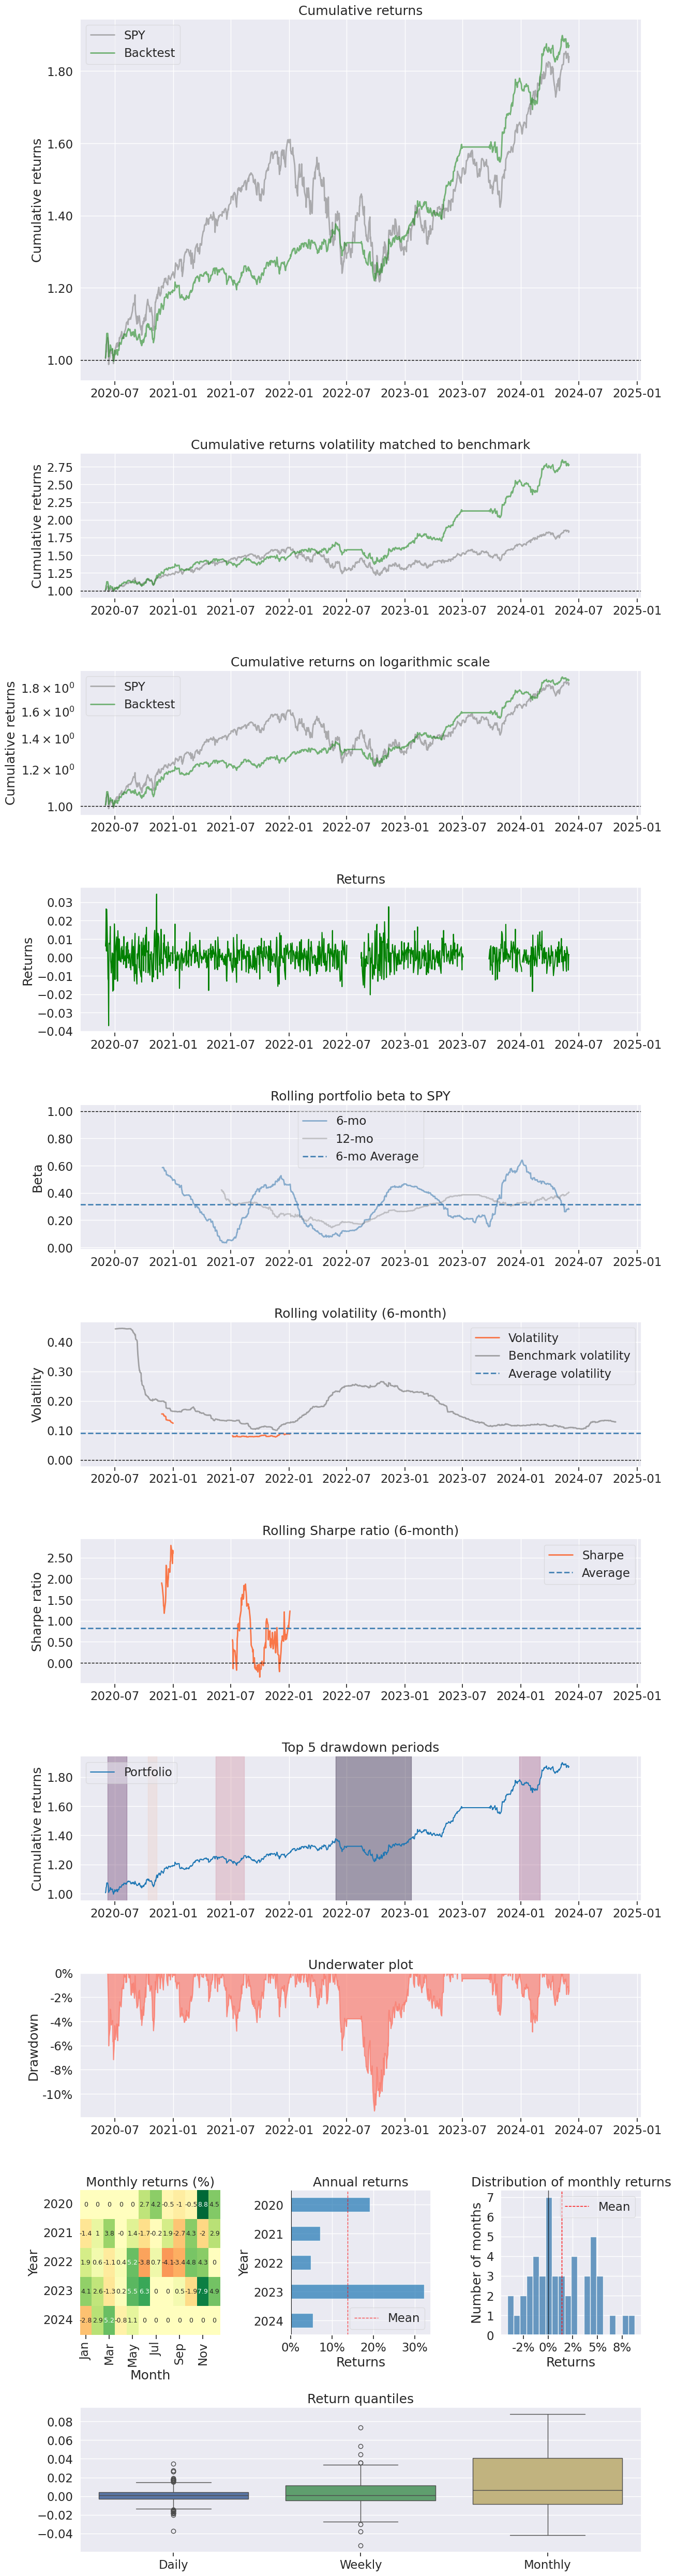

In [ ]:
import pyfolio as pf

pf.create_returns_tear_sheet(
    (r.loc["2020-06-01":"2024-06-01"]) / 10, benchmark_rets=bench_close
)

Start date,2020-06-01
End date,2024-05-31
Total months,48
,Backtest
Annual return,31.92%
Cumulative returns,202.863%
Annual volatility,21.618%
Sharpe ratio,1.40
Calmar ratio,1.41
Stability,0.81
Max drawdown,-22.691%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.69,2021-11-23,2022-09-26,2023-01-13,299
1,14.08,2020-06-08,2020-06-26,2020-08-10,46
2,13.10,2023-07-31,2023-10-27,2023-11-14,77
3,10.11,2021-05-07,2021-07-19,2021-08-12,70
4,10.02,2023-02-16,2023-03-17,2023-06-06,79


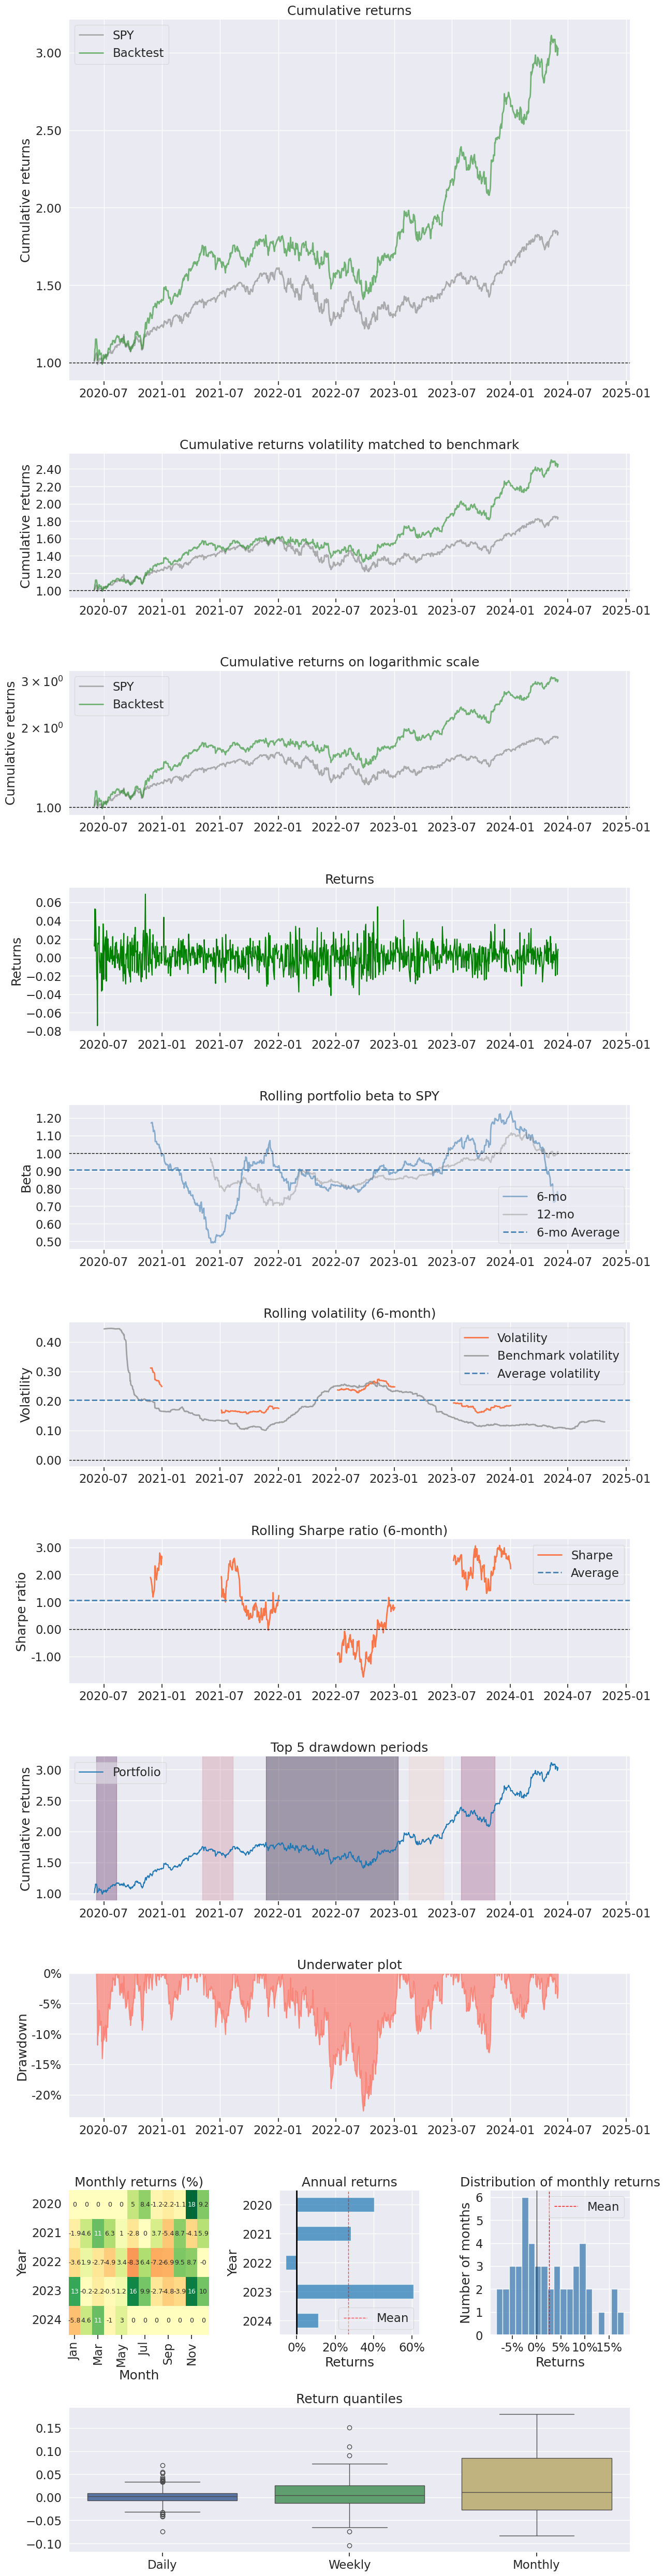

In [ ]:
pf.create_returns_tear_sheet(
    r_long.loc["2020-06-01":"2024-06-01"] / 5, benchmark_rets=bench_close
)

Start date,2020-06-01
End date,2024-05-31
Total months,48
,Backtest
Annual return,3.35%
Cumulative returns,14.087%
Annual volatility,10.679%
Sharpe ratio,0.39
Calmar ratio,0.27
Stability,0.55
Max drawdown,-12.273%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,12.27,2021-01-04,2021-05-04,2022-02-23,298
1,8.65,2022-03-14,2022-03-29,2022-05-06,40
2,8.43,2024-01-18,2024-02-01,NaT,NaN
3,7.24,2022-06-17,2023-02-02,2023-03-09,190
4,6.87,2023-03-23,2023-04-19,2023-05-10,35


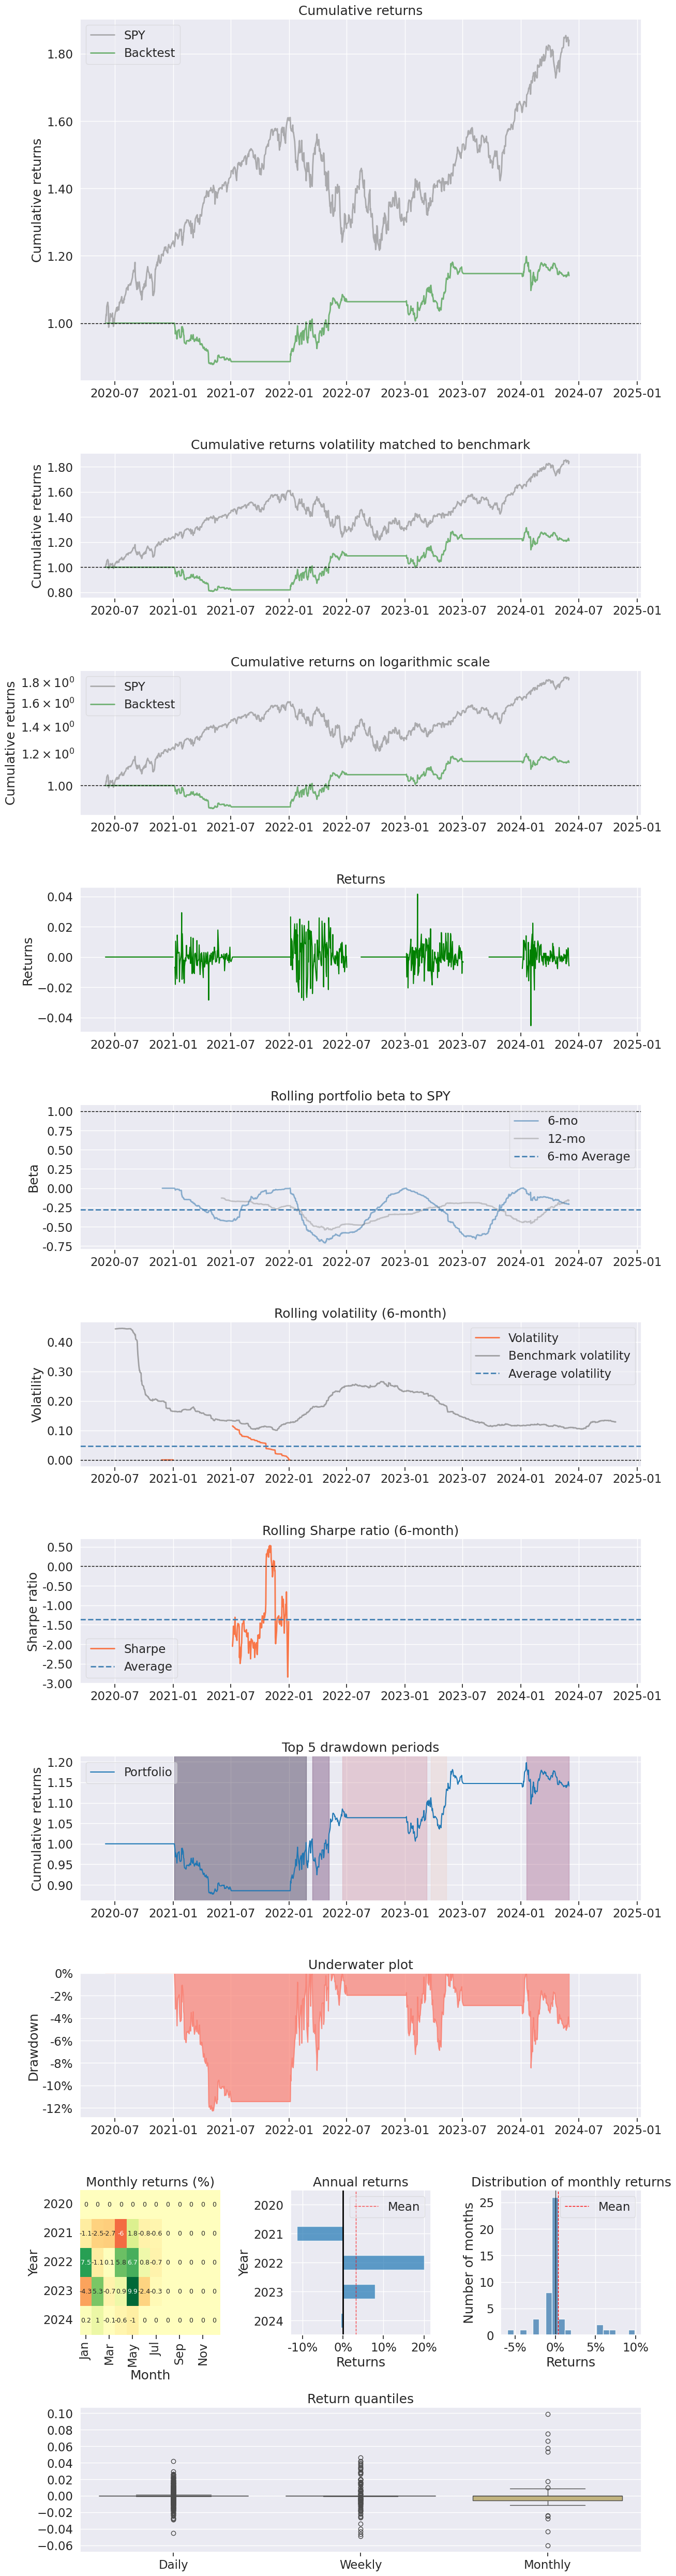

In [ ]:
pf.create_returns_tear_sheet(
    r_short.loc["2020-06-01":"2024-06-01"] / 5, benchmark_rets=bench_close
)